# Fine-tuning CNN Virus model for YFV: Train

## Objectives and Plan

**Overall plan**: use 50-mer simreads from specificly selected 5 YFV reference sequences to fine tune the CNN Virus model. The reference sequences are selected as progressively distant from the training reference sequence.

**In the notebook**:
- create the fasta file with 5 reference sequences
- create the 50-mer simreads from these sequences
- test the model training with a few epochs

List of 5 reference sequences accession:
- KU978763: West African II : Nigeria 1946
- AY968064: Angolan : Angola 1971
- JN620362: East-Central African Uganda 2010
- MF370549: South american I : Brazil 2015
- MF004382: South american II : Bolivia 1999

*Reference*:

<details>
  <summary>Email Nicolas Berthet Dec 13, 2024</summary>
  <p>Comme la séquence de référence qui a été utilisé pour entrainer le modèle était celle du vaccin 17D, qui appartient au clade West African II, je propose d’utiliser les séquences ci-dessous :</p>
  <ul>
    <li>West African II : Nigeria 1946 KU978763</li>
    <li>Angolan : Angola 1971 AY968064</li>
    <li>East-Central African Uganda 2010 JN620362</li>
    <li>South american I : Brazil 2015 MF370549</li>
    <li>South american II : Bolivia 1999 MF004382</li>
  </ul>
  <p>L’idée d’entrainer avec une nouvelle séquence à chaque fois ? Et de voir si on couvre la totalité du génome ?</p>
  <p>Bon weekend</p>
  <p>Amicalement</p>
  <p>Nicolas</p>
</details>

# 1. Imports and setup environment

In [ ]:
# Install required custom packages if not installed yet.
import importlib.util
if not importlib.util.find_spec('eccore'):
    print('installing package: `eccore`')
    ! pip install -qqU eccore
else:
    print('`eccore` already installed')
if not importlib.util.find_spec('metagentorch'):
    print('installing package: `metagentorch')
    ! pip install -qqU metagentorch
else:
    print('`metagentorch` already installed')

`eccore` already installed
`metagentorch` already installed


In [ ]:
# Import all required packages
import os
from datetime import datetime, timedelta
import json
import matplotlib.pyplot as plt
import uuid
from configparser import ConfigParser
from functools import partial
from pathlib import Path
from pprint import pprint
from typing import Any, Dict, Generator, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from eccore.core import files_in_tree, get_config_value
from eccore.ipython import nb_setup
from nbdev import show_doc
from tqdm.notebook import tqdm, trange

# Setup the notebook for development
nb_setup()

os.environ['KERAS_BACKEND'] = "torch"
import keras
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from metagentorch.art import ArtIllumina
from metagentorch.cnn_virus.architecture import create_model_original
from metagentorch.cnn_virus.data import AlnFileReader,TextFileDataset, OriginalLabels
from metagentorch.core import ProjectFileSystem, list_available_devices, TextFileBaseReader

Set autoreload mode


List all computing devices available on the machine

In [ ]:
list_available_devices()

CUDA available: True
Number of CUDA devices: 1
CUDA Device 0: NVIDIA GeForce GTX 1050
CPU available: cpu


# 2. Setup paths to files

Key folders and system information

In [ ]:
pfs = ProjectFileSystem()
pfs.info()

Running linux on local computer
Device's home directory: /home/vtec
Project file structure:
 - Root ........ /home/vtec/projects/bio/metagentorch 
 - Data Dir .... /home/vtec/projects/bio/metagentorch/data 
 - Notebooks ... /home/vtec/projects/bio/metagentorch/nbs


Set the path to the pretained model and the virus labels mapping file:

- `p2model`: path to file with saved original pretrained model
- `p2virus_labels` path to file with virus names and labels mapping for original model

In [ ]:
p2model = pfs.data / 'saved/cnn_virus_original/pretrained_model.h5'
assert p2model.is_file(), f"No file found at {p2model.absolute()}"

p2virus_labels = pfs.data / 'CNN_Virus_data/virus_name_mapping'
assert p2virus_labels.is_file(), f"No file found at {p2virus_labels.absolute()}"

# 3. Load and prepare model for finetuning

Load the original model with parameters

In [ ]:
model = create_model_original()
model.summary()

Creating CNN Model (Original)
Loading parameters from pretrained_model.h5
Created pretrained model
Model will run on: cuda


Model: "CNN_Virus"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input-seq           │ (None, 50, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-1 (Conv1D)     │ (None, 50, 512)   │     13,312 │ input-seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-1                │ (None, 50, 512)   │      2,048 │ conv-1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool-1           │ (None, 25, 512)   │          0 │ bn-1[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-2 (Conv1D)     │ (None, 25, 512)   │  1,311,232 │ maxpool-1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-2                │ (None, 25, 512)   │      2,048 │ conv-2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool-2           │ (None, 13, 512)   │          0 │ bn-2[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-3 (Conv1D)     │ (None, 13, 1024)  │  3,671,040 │ maxpool-2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv-4 (Conv1D)     │ (None, 13, 1024)  │  7,341,056 │ conv-3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-3                │ (None, 13, 1024)  │      4,096 │ conv-4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool-3           │ (None, 7, 1024)   │          0 │ bn-3[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 7168)      │          0 │ maxpool-3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense-1 (Dense)     │ (None, 1024)      │  7,341,056 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-4                │ (None, 1024)      │      4,096 │ dense-1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ do-1 (Dropout)      │ (None, 1024)      │          0 │ bn-4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ labels (Dense)      │ (None, 187)       │    191,675 │ do-1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 1211)      │          0 │ do-1[0][0],       │
│ (Concatenate)       │                   │            │ labels[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense-2 (Dense)     │ (None, 1024)      │  1,241,088 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn-5                │ (None, 1024)      │      4,096 │ dense-2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos (Dense)         │ (None, 10)        │     10,250 │ bn-5[0][0]      

 Total params: 21,137,093 (80.63 MB)

 Trainable params: 21,128,901 (80.60 MB)

 Non-trainable params: 8,192 (32.00 KB)

Review trainable parameters for each layer

In [ ]:
print('\n'.join([f"{i:2d}:  {l.name:10s} is trainable: {l.trainable}" for i,l in enumerate(model.layers)]))

 0:  input-seq  is trainable: True
 1:  conv-1     is trainable: True
 2:  bn-1       is trainable: True
 3:  maxpool-1  is trainable: True
 4:  conv-2     is trainable: True
 5:  bn-2       is trainable: True
 6:  maxpool-2  is trainable: True
 7:  conv-3     is trainable: True
 8:  conv-4     is trainable: True
 9:  bn-3       is trainable: True
10:  maxpool-3  is trainable: True
11:  flatten    is trainable: True
12:  dense-1    is trainable: True
13:  bn-4       is trainable: True
14:  do-1       is trainable: True
15:  labels     is trainable: True
16:  concat     is trainable: True
17:  dense-2    is trainable: True
18:  bn-5       is trainable: True
19:  pos        is trainable: True


Protect key layers of the original model:
- Make all feature extraction features no trainable to protect the original model.
- Make dense layers after the flatten layer as trainable for fine tuning

In [ ]:
for l in model.layers[:12]:
    l.trainable = False
print('\n'.join([f"{i:2d}:  {l.name:10s} is trainable: {l.trainable}" for i,l in enumerate(model.layers)]))

 0:  input-seq  is trainable: False
 1:  conv-1     is trainable: False
 2:  bn-1       is trainable: False
 3:  maxpool-1  is trainable: False
 4:  conv-2     is trainable: False
 5:  bn-2       is trainable: False
 6:  maxpool-2  is trainable: False
 7:  conv-3     is trainable: False
 8:  conv-4     is trainable: False
 9:  bn-3       is trainable: False
10:  maxpool-3  is trainable: False
11:  flatten    is trainable: False
12:  dense-1    is trainable: True
13:  bn-4       is trainable: True
14:  do-1       is trainable: True
15:  labels     is trainable: True
16:  concat     is trainable: True
17:  dense-2    is trainable: True
18:  bn-5       is trainable: True
19:  pos        is trainable: True


# 4. Train frozen model

In [ ]:
from keras.optimizers import Adam                                   # type: ignore
from keras.losses import CategoricalCrossentropy                    # type: ignore
from keras.metrics import CategoricalAccuracy, Recall, Precision    # type: ignore
from keras.callbacks import EarlyStopping, ModelCheckpoint          # type: ignore  

In [ ]:
p2finetuning_ds = pfs.data / 'ncbi/ds/yf/finetuning'
assert p2finetuning_ds.is_dir()
files_in_tree(p2finetuning_ds);

yf
  |--finetuning
  |    |--dataset-sizes.cfg (0)
  |    |--50mers_2025-03-04_22h16m_test (1)
  |    |--50mers_2025-03-04_22h16m_training_10k (2)
  |    |--50mers_2025-03-04_22h16m_validation (3)
  |    |--50mers_2025-03-04_22h16m_training (4)


In [ ]:
ds_set = '50mers_2025-03-04_22h16m'

p2finetune_train_ds = p2finetuning_ds / f"{ds_set}_training"
p2finetune_val_ds = p2finetuning_ds / f"{ds_set}_validation"
p2finetune_test_ds = p2finetuning_ds / f"{ds_set}_test"

assert p2finetune_train_ds.is_file() and p2finetune_val_ds.is_file() and p2finetune_test_ds.is_file()

/home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/50mers_2025-03-04_22h16m_test


Define the nbr of steps per epoch for training and and nbr of step for validation:

In [ ]:
p2sizes = p2finetuning_ds / 'dataset-sizes.cfg'
nb_train_samples = int(get_config_value('NB SAMPLES', p2finetune_train_ds.stem, p2sizes))
nb_val_samples = int(get_config_value('NB SAMPLES', p2finetune_val_ds.stem, p2sizes))
print(f"- {nb_train_samples:,d} training samples\n- {nb_val_samples:,d} validation samples")

Using config file at /home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/dataset-sizes.cfg
Using config file at /home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/dataset-sizes.cfg
- 614,000 training samples
- 50,000 validation samples


## Training loop

After experiment on my local machine (1 epoch for the full training set with validation) one epoch takes about 26 min total time

In [ ]:
nb_epochs = 30
print(f"Estimated time: {int(26/60 * nb_epochs):,d} hours")

Estimated time: 13 hours


In [ ]:
lr = 1e-4
bs_train = 512
bs_val = 2048

ds_train = TextFileDataset(p2finetune_train_ds)
dl_train = DataLoader(ds_train, batch_size=bs_train, shuffle=False, pin_memory=True, drop_last=True)

ds_val = TextFileDataset(p2finetune_val_ds)
dl_val = DataLoader(ds_val, batch_size=bs_val, shuffle=False, pin_memory=True, drop_last=True)

loss = CategoricalCrossentropy(name='crossentropy')
lbl_acc, pos_acc = CategoricalAccuracy(name='acc'),CategoricalAccuracy(name='acc')

model = create_model_original()

model.compile(
    optimizer=Adam(learning_rate=lr),
    loss=loss,
    metrics=[lbl_acc, pos_acc],
)

Creating CNN Model (Original)
Loading parameters from pretrained_model.h5
Created pretrained model
Model will run on: cuda


In [ ]:
print(f"Each epoch should run {nb_train_samples//bs_train:,d} steps/batches for each epoch")
print(f"Validation will take {nb_val_samples//bs_val:,d} steps/batches")

print(f"Parameters: \n - {nb_epochs} epochs \n - {lr:.2e} learning rate")

Each epoch should run 1,199 steps/batches for each epoch
Validation will take 24 steps/batches
Parameters: 
 - 30 epochs 
 - 1.00e-04 learning rate


In [ ]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = datetime.now()
hist = model.fit(
    dl_train, 
    epochs=nb_epochs,
    # steps_per_epoch=10,
    validation_data=dl_val,
    validation_steps=nb_val_samples//bs_val,
    shuffle=False,
    callbacks=[es],
    verbose=1,
    )
training_time = int((datetime.now() - start_time).total_seconds())
print(f"Trained for {training_time//86400}d {training_time%86400//3600}h {training_time%3600//60}m")

Epoch 1/30
   1199/Unknown 1596s 1s/step - labels_acc: 0.7528 - labels_loss: 2.6452 - loss: 6.5354 - pos_acc: 0.6012 - pos_loss: 3.8902

/home/vtec/miniconda3/envs/torch/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1199/1199 ━━━━━━━━━━━━━━━━━━━━ 1617s 1s/step - labels_acc: 0.7529 - labels_loss: 2.6440 - loss: 6.5336 - pos_acc: 0.6013 - pos_loss: 3.8896 - val_labels_acc: 0.9328 - val_labels_loss: 0.3109 - val_loss: 2.1720 - val_pos_acc: 0.7068 - val_pos_loss: 1.8611
Epoch 2/30
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 1605s 1s/step - labels_acc: 0.9281 - labels_loss: 0.3128 - loss: 1.7755 - pos_acc: 0.7340 - pos_loss: 1.4627 - val_labels_acc: 0.9481 - val_labels_loss: 0.1949 - val_loss: 0.8915 - val_pos_acc: 0.8099 - val_pos_loss: 0.6966
Epoch 3/30
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 1606s 1s/step - labels_acc: 0.9427 - labels_loss: 0.2033 - loss: 0.7933 - pos_acc: 0.8276 - pos_loss: 0.5900 - val_labels_acc: 0.9582 - val_labels_loss: 0.1465 - val_loss: 0.5322 - val_pos_acc: 0.8759 - val_pos_loss: 0.3857
Epoch 4/30
1199/1199 ━━━━━━━━━━━━━━━━━━━━ 1606s 1s/step - labels_acc: 0.9535 - labels_loss: 0.1518 - loss: 0.4853 - pos_acc: 0.8908 - pos_loss: 0.3334 - val_labels_acc: 0.9643 - val_labels_loss: 0.1221 - val_loss:

## Training Statistics and Training Curves

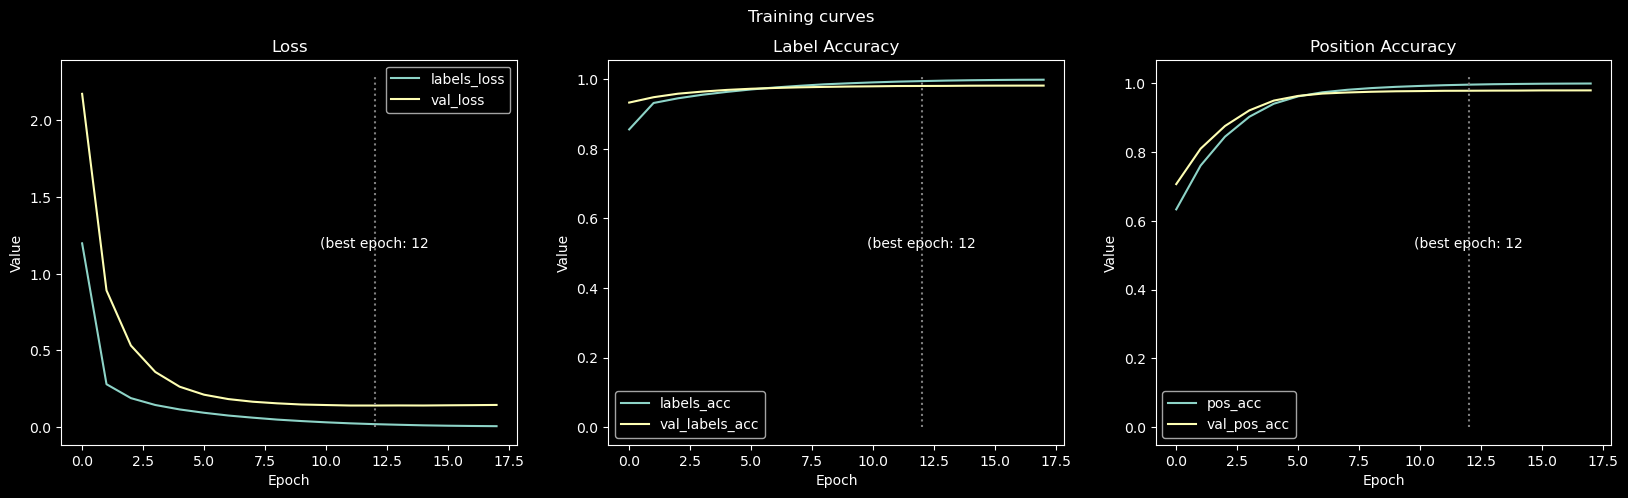

In [ ]:
first_idx = 0
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
train_stats = pd.DataFrame(hist.history)
fig.suptitle(f"Training curves")
train_stats.iloc[first_idx:].loc[:, ['labels_loss', 'val_loss']].plot(title='Loss', ax=ax1);
train_stats.iloc[first_idx:].loc[:, ['labels_acc', 'val_labels_acc']].plot(title='Label Accuracy', ax=ax2);
train_stats.iloc[first_idx:].loc[:, ['pos_acc', 'val_pos_acc']].plot(title='Position Accuracy', ax=ax3);
for ax in (ax1, ax2, ax3):
    ax.set_xlabel('Epoch')
    ax.vlines(es.best_epoch,0, ax.get_ylim()[1], colors='gray', linestyles='dotted');
    ax.set_ylabel('Value')
    ax.text(es.best_epoch, ax.get_ylim()[1]/2, f"(best epoch: {es.best_epoch}", transform=ax.transData, ha='center', va='center')

## Save weights, training curves and training statistics

In [ ]:
p2finetuned_models = pfs.data / 'saved/cnn_virus_finetuned'
assert p2finetuned_models.is_dir()

In [ ]:
timestamp = datetime.now().strftime('%Y-%m-%d_%Hh%Mm')
uid = uuid.uuid4()
timestamp = '2025-03-05_07h41m'
uid = '7a534024-be3c-47e9-8323-9caeb3febaa7'
fname_seed = f"yfv_5seq_{timestamp}_{uid}"
p2model_weights = p2finetuned_models / f"{fname_seed}.weights.h5"
p2training_curves = p2finetuned_models / f"training_curves./{fname_seed}.curves.svg"
p2training_stats =  p2finetuned_models / f"training_stats/{fname_seed}.train_stats.csv"
# model.save_weights(p2model_weights)
# fig.savefig(p2training_curves)
# train_stats.to_csv(p2training_stats)
print(f"Weights saved in:             {p2model_weights.name}")
print(f"Training curves saved in:     {p2training_curves.parent.name}/{p2training_curves.name}")
print(f"Training statistics saved in: {p2training_stats.parent.name}/{p2training_stats.name}")

Weights saved in:             yfv_5seq_2025-03-05_07h41m_7a534024-be3c-47e9-8323-9caeb3febaa7.weights.h5
Training curves saved in:     training_curves./yfv_5seq_2025-03-05_07h41m_7a534024-be3c-47e9-8323-9caeb3febaa7.curves.svg
Training statistics saved in: training_stats/yfv_5seq_2025-03-05_07h41m_7a534024-be3c-47e9-8323-9caeb3febaa7.train_stats.csv


## Test model

In [ ]:
ds_test = TextFileDataset(p2finetune_test_ds)
dl_test = DataLoader(ds_test, batch_size=bs_val, shuffle=False, pin_memory=True, drop_last=True)

In [ ]:
p2sizes = p2finetuning_ds / 'dataset-sizes.cfg'
nb_test_samples = int(get_config_value('NB SAMPLES', p2finetune_test_ds.name, p2sizes))
print(f"{nb_test_samples:,d} test samples")

Using config file at /home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/dataset-sizes.cfg
50,000 test samples


In [ ]:
test_res = model.evaluate(
    dl_test, 
    steps=nb_test_samples // bs_val,
    )
print('Test Set test_Results:')
print('\n'.join([f"test_{n:10s}: {r:.4f}" for n,r in zip('loss label_loss pos_loss label_acc pos_acc'.split(' '),test_res)]))

24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 732ms/step - labels_acc: 0.9622 - labels_loss: 0.1702 - loss: 0.3335 - pos_acc: 0.9604 - pos_loss: 0.1633
Test Set test_Results:
test_loss      : 0.3433
test_label_loss: 0.1765
test_pos_loss  : 0.1668
test_label_acc : 0.9610
test_pos_acc   : 0.9600


## Save model metadata

In [ ]:
p2json = p2finetuned_models / '_model_stats.json'

In [ ]:
train_stats_dict = {
    'nb epochs': nb_epochs, 'lr': lr, 'best_epoch': es.best_epoch,
    'training ds': str(p2finetune_train_ds.absolute()), 
    'nb training samples': nb_train_samples, 'training bs': bs_train, 
    'validation ds': str(p2finetune_val_ds.absolute()),
    'nb validation samples': nb_val_samples, 'validation bs': bs_val,
    'training time': training_time,
    'training curves': str(p2training_curves.absolute()),
    'training stats': str(p2training_stats.absolute()),
    }
train_stats_dict.update(train_stats.iloc[es.best_epoch,:].to_dict())
train_stats_dict

{'nb_epochs': 30,
 'lr': 0.0001,
 'training_ds': '/home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/50mers_2025-03-04_22h16m_training',
 'train_samples': 614000,
 'train_bs': 512,
 'validation_ds': '/home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/50mers_2025-03-04_22h16m_validation',
 'validation_samples': 50000,
 'validation_bs': 2048,
 'training_curves': '/home/vtec/projects/bio/metagentorch/data/saved/cnn_virus_finetuned/training_curves./yfv_5seq_2025-03-05_07h41m_7a534024-be3c-47e9-8323-9caeb3febaa7.curves.svg',
 'training_stats': '/home/vtec/projects/bio/metagentorch/data/saved/cnn_virus_finetuned/training_stats/yfv_5seq_2025-03-05_07h41m_7a534024-be3c-47e9-8323-9caeb3febaa7.train_stats.csv'}

In [ ]:
test_stats_dict = {
    'test ds': str(p2finetune_test_ds.absolute()),
    'nb test samples': nb_test_samples, 'bs test': bs_val,
    }
test_stats_dict.update({f"test_{k}":v for k,v in zip('loss label_loss pos_loss label_acc pos_acc'.split(' '),test_res)})
test_stats_dict

{'test_ds': '/home/vtec/projects/bio/metagentorch/data/ncbi/ds/yf/finetuning/50mers_2025-03-04_22h16m_test',
 'test_samples': 50000,
 'bs_test': 2048}

In [ ]:
run_stats = train_stats_dict
run_stats.update(test_stats_dict)

# add weights, stats and 
run_stats['saved time'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

model_stats_json = json.load(p2json.open('r'))
model_stats_json[fname_seed] = run_stats
json.dump(model_stats_json, p2json.open('w'), indent=4)